# HAR-X Model on the MALL 5-min Feature Set


**Purpose:** The purpose of this notebook is to compute the out-of-sample forecast performance of the Heterogeneous Autoregressive model with exogenous predictors (HAR-X) on the $\mathcal{M}_{\mathrm{ALL}}$ 5-min feature set for the EURO STOXX 50 index over the period 1999--2020, following the methodology of Christensen et al. (2023).

The HAR-X model extends the baseline HAR specification by augmenting the daily, weekly, and monthly realized-variance block with a parsimonious set of macro-financial and cross-market predictors. In line with the reference paper, the benchmark HAR-X model is estimated by Ordinary Least Squares (OLS) on the predictors in their chosen economic transformations, without standardizing them.

The final MALL feature set used in this notebook is:

- `RVD`, `RVW`, `RVM`
- `VSTOXX`
- `CISS`
- `logEPU_1m_lag`
- `EURUSD_ret`
- `BRENT_ret`
- `NIKKEI_ret`, `NIKKEI_sq`
- `SP500_ret_lag`, `SP500_sq_lag`
- `M1W`, `M1M`

The model is defined as:

$$RV_{t+1} = \beta_0 + \beta' Z_t + \varepsilon_{t+1},$$

where $Z_t$ denotes the final MALL predictor vector listed above. The model is estimated using a rolling window of fixed length equal to the combined training and validation sample, rolling forward one day at a time across the test period.

## 1. Loading Data
Loading in data from the `MALL_5min.csv` file.


In [4]:
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

# Load MALL dataset
file_path = "/Users/tobiasbergdahlpersson/Documents/SSE/MSc Thesis/5-min RV/Cleaned Data Sets/MALL_5min.csv"
MALL = pd.read_csv(file_path, index_col="Date", parse_dates=True)

print(f"Shape: {MALL.shape}")
print(f"Date range: {MALL.index[0].date()} to {MALL.index[-1].date()}")
print(f"NaN values: {MALL.isna().sum().sum()}")
MALL.head()


Shape: (5489, 31)
Date range: 1999-01-05 to 2020-08-06
NaN values: 0


,RVD,RVW,RVM,logRVD,logRVW,logRVM,RVD_pos,RVD_neg,RD_neg,RW_neg,...,BRENT,BRENT_ret,NIKKEI_ret,NIKKEI_sq,SP500_ret_lag,SP500_sq_lag,M1W,M1M,RV_target,logRV_target
Date,,,,,,,,,,,,,,,,,,,,,
1999-01-05,0.000106,0.000089,0.000141,-9.153100,-9.328531,-8.866447,0.000071,0.000035,0.000000,0.000000,...,10.30,-0.060282,-0.013746,0.000189,-0.000920,8.458434e-07,0.087690,0.126206,0.000047,-9.966398
1999-01-06,0.000047,0.000090,0.000132,-9.966398,-9.316927,-8.935760,0.000038,0.000009,0.000000,0.000000,...,10.67,0.035292,0.017657,0.000312,0.013491,1.819949e-04,0.100143,0.187219,0.000237,-8.347779
1999-01-07,0.000237,0.000123,0.000131,-8.347779,-9.004761,-8.938374,0.000110,0.000127,-0.012859,0.000000,...,11.08,0.037706,0.005044,0.000025,0.021899,4.795626e-04,0.078881,0.184020,0.000168,-8.689606
1999-01-08,0.000168,0.000146,0.000114,-8.689606,-8.832472,-9.082830,0.000079,0.000089,-0.005883,0.000000,...,11.70,0.054447,-0.010751,0.000116,-0.002053,4.216638e-06,0.078883,0.165510,0.000282,-8.175339
1999-01-11,0.000282,0.000168,0.000117,-8.175339,-8.692020,-9.056351,0.000067,0.000215,-0.025309,-0.001398,...,12.07,0.031134,-0.001744,0.000003,0.004212,1.774503e-05,0.001055,0.140613,0.000191,-8.565468


## 2. Data Split
### 2.1 Train / Validation / Test Split (70 / 10 / 20)


Following Christensen et al. (2023), we split the sample into a training set (70%), validation set (10%), and test set (20%). The test set is reserved exclusively for out-of-sample evaluation. For the non-regularized HAR-X model, the training and validation blocks are then merged into a single rolling estimation window, mirroring the paper's benchmark HAR implementation.


In [8]:
# Train / Validation / Test split (70 / 10 / 20)
n = len(MALL)
n_train = int(np.floor(0.70 * n))
n_val = int(np.floor(0.10 * n))
n_test = n - n_train - n_val

train_idx = MALL.index[:n_train]
val_idx = MALL.index[n_train:n_train + n_val]
test_idx = MALL.index[n_train + n_val:]

print(f"Total observations: {n}")
print(f"\nTrain:      {train_idx[0].date()} to {train_idx[-1].date()} ({n_train} obs, {n_train/n*100:.1f}%)")
print(f"Validation: {val_idx[0].date()} to {val_idx[-1].date()} ({n_val} obs, {n_val/n*100:.1f}%)")
print(f"Test:       {test_idx[0].date()} to {test_idx[-1].date()} ({n_test} obs, {n_test/n*100:.1f}%)")


Total observations: 5489

Train:      1999-01-05 to 2014-02-26 (3842 obs, 70.0%)
Validation: 2014-02-27 to 2016-04-20 (548 obs, 10.0%)
Test:       2016-04-21 to 2020-08-06 (1099 obs, 20.0%)


## 3. HAR-X Model
### 3.1 Model Specification


The HAR-X specification estimated in this notebook is:

$$RV_{t+1} = \beta_0 + \beta_d RVD_t + \beta_w RVW_t + \beta_m RVM_t + \gamma' X_t + \varepsilon_{t+1},$$

where $X_t$ contains the additional MALL predictors beyond the standard HAR volatility block. In line with the reference paper, the predictors enter the model in their original transformed units rather than in standardized form.


### 3.2 Feature Set Construction
Extracting the dependent and independent variables relevant for the HAR-X model.


In [13]:
# Define target and final MALL feature set for HAR-X
feature_cols = [
    "RVD", "RVW", "RVM",
    "VSTOXX", "CISS", "logEPU_1m_lag",
    "EURUSD_ret", "BRENT_ret",
    "NIKKEI_ret", "NIKKEI_sq",
    "SP500_ret_lag", "SP500_sq_lag",
    "M1W", "M1M"
]

y = MALL["RV_target"]
X_HARX = MALL[feature_cols]

print("Target variable: RV_target")
print("Predictors:")
for col in feature_cols:
    print(f"  - {col}")

print("\nFirst few rows:")
print(pd.concat([y, X_HARX], axis=1).head())


Target variable: RV_target
Predictors:
  - RVD
  - RVW
  - RVM
  - VSTOXX
  - CISS
  - logEPU_1m_lag
  - EURUSD_ret
  - BRENT_ret
  - NIKKEI_ret
  - NIKKEI_sq
  - SP500_ret_lag
  - SP500_sq_lag
  - M1W
  - M1M

First few rows:
            RV_target       RVD       RVW       RVM   VSTOXX    CISS  \
Date                                                                   
1999-01-05   0.000047  0.000106  0.000089  0.000141  29.6912  0.2085   
1999-01-06   0.000237  0.000047  0.000090  0.000132  25.1670  0.2214   
1999-01-07   0.000168  0.000237  0.000123  0.000131  32.5205  0.2254   
1999-01-08   0.000282  0.000168  0.000146  0.000114  33.2296  0.2297   
1999-01-11   0.000191  0.000282  0.000168  0.000117  36.8411  0.2583   

            logEPU_1m_lag  EURUSD_ret  BRENT_ret  NIKKEI_ret  NIKKEI_sq  \
Date                                                                      
1999-01-05        4.71861    0.000085  -0.060282   -0.013746   0.000189   
1999-01-06        4.71861   -0.003994   0.0

### 3.3 Rolling Window Estimation and Forecasting

Following Christensen et al. (2023), the HAR-X model is estimated via OLS using a rolling window of fixed length equal to the combined training and validation set. The window rolls forward one day at a time across the test set, producing one-step-ahead forecasts. Negative forecasts are replaced by the minimum in-sample realized variance, in line with the safeguard used throughout the benchmark-model implementation.


In [16]:
# Rolling window length = train + validation
window = n_train + n_val

forecasts_HARX = []
dates_test = []

for i in range(n_test):
    # Extract rolling window
    X_window = X_HARX.iloc[i:i + window].values
    y_window = y.iloc[i:i + window].values

    # OLS estimation
    model = LinearRegression()
    model.fit(X_window, y_window)

    # One-step-ahead forecast using time t predictors
    X_forecast = X_HARX.iloc[i + window].values.reshape(1, -1)
    forecast = model.predict(X_forecast)[0]

    # Replace negative forecasts with the in-window minimum realized variance
    min_rv = y_window.min()
    forecast = max(forecast, min_rv)

    forecasts_HARX.append(forecast)
    dates_test.append(MALL.index[i + window])

print(f"Forecasts generated: {len(forecasts_HARX)}")
print(f"Forecast period: {dates_test[0].date()} to {dates_test[-1].date()}")


Forecasts generated: 1099
Forecast period: 2016-04-21 to 2020-08-06


### 3.4 Out-of-Sample Performance Evaluation


Following Christensen et al. (2023), out-of-sample forecast accuracy is evaluated using the Mean Squared Error (MSE):

$$MSE = \frac{1}{T}\sum_{t \in \text{test}} (RV_{t+1} - \hat{f}(Z_t))^2,$$

where $\hat{f}(Z_t)$ is the one-step-ahead forecast from the HAR-X model and $T$ is the number of test observations.


In [20]:
# Collect results
results_HARX = pd.DataFrame({
    "RV_actual": y.loc[dates_test].values,
    "RV_forecast": forecasts_HARX
}, index=dates_test)

# Compute out-of-sample MSE
mse_HARX = np.mean((results_HARX["RV_actual"] - results_HARX["RV_forecast"]) ** 2)

print(f"Out-of-sample MSE (HARX): {mse_HARX:.6e}")
print("\nFirst few forecasts vs actuals:")
print(results_HARX.head(10).to_string())


Out-of-sample MSE (HARX): 5.277243e-08

First few forecasts vs actuals:
            RV_actual  RV_forecast
2016-04-21   0.000053     0.000039
2016-04-22   0.000081     0.000057
2016-04-25   0.000066     0.000073
2016-04-26   0.000059     0.000072
2016-04-27   0.000097     0.000076
2016-04-28   0.000147     0.000046
2016-04-29   0.000095     0.000160
2016-05-02   0.000105     0.000119
2016-05-03   0.000085     0.000176
2016-05-04   0.000093     0.000213


### 3.4.1 Save Forecasts


In [23]:
# Paths
forecast_path = "/Users/tobiasbergdahlpersson/Documents/SSE/MSc Thesis/5-min RV/Cleaned Data Sets/Forecasts 5-min/MALL/Benchmark Models"
mse_path = "/Users/tobiasbergdahlpersson/Documents/SSE/MSc Thesis/5-min RV/Cleaned Data Sets/MSE 5-min/MALL/Benchmark Models"

os.makedirs(forecast_path, exist_ok=True)
os.makedirs(mse_path, exist_ok=True)

# Save forecasts
results_HARX.to_csv(os.path.join(forecast_path, "forecasts_HARX.csv"))

# Create MSE summary
mse_summary_HARX = pd.DataFrame({
    "Model": ["HARX"],
    "MSE": [mse_HARX],
    "RMSE": [np.sqrt(mse_HARX)],
    "MAE": [np.mean(np.abs(results_HARX["RV_actual"] - results_HARX["RV_forecast"]))],
    "Mean_Error": [np.mean(results_HARX["RV_actual"] - results_HARX["RV_forecast"])]
}).set_index("Model")

mse_summary_HARX.to_csv(os.path.join(mse_path, "mse_summary_HARX.csv"))

print(f"Forecasts saved to: {forecast_path}")
print(f"MSE saved to: {mse_path}")
print("Files saved:")
print(f"  - forecasts_HARX.csv ({len(results_HARX)} rows)")
print("  - mse_summary_HARX.csv")
print(f"\nHARX MSE: {mse_HARX:.6e}")


Forecasts saved to: /Users/tobiasbergdahlpersson/Documents/SSE/MSc Thesis/5-min RV/Cleaned Data Sets/Forecasts 5-min/MALL/Benchmark Models
MSE saved to: /Users/tobiasbergdahlpersson/Documents/SSE/MSc Thesis/5-min RV/Cleaned Data Sets/MSE 5-min/MALL/Benchmark Models
Files saved:
  - forecasts_HARX.csv (1099 rows)
  - mse_summary_HARX.csv

HARX MSE: 5.277243e-08


## 4. Results
### 4.1 Forecast Visualization


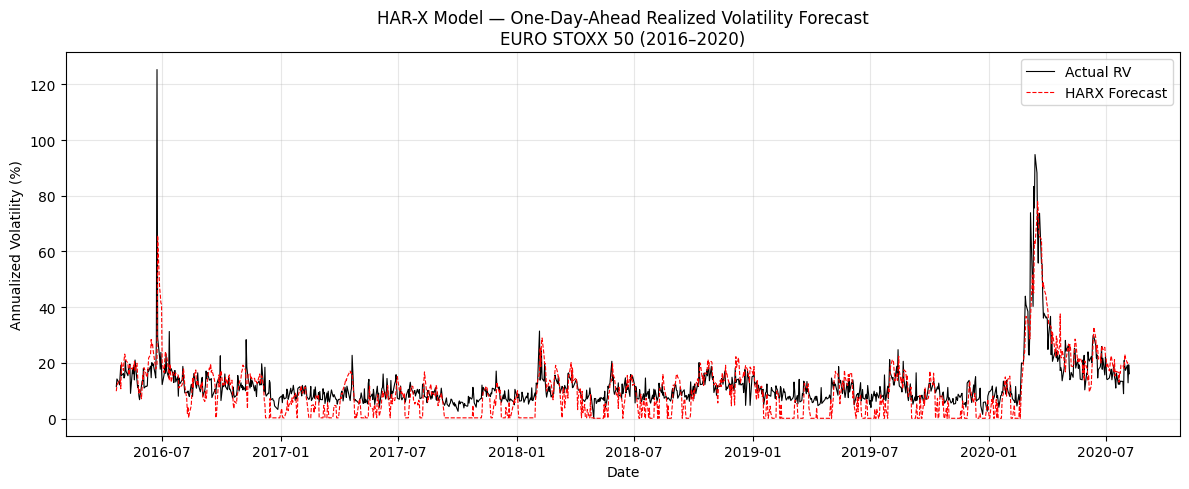


Summary of forecast errors:
Mean error:  8.305782e-06
RMSE:        2.297225e-04
MAE:         5.449018e-05


In [26]:
# Convert to annualized volatility for readability
results_plot = pd.DataFrame({
    "Actual": np.sqrt(results_HARX["RV_actual"] * 252) * 100,
    "Forecast": np.sqrt(results_HARX["RV_forecast"] * 252) * 100
}, index=results_HARX.index)

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(results_plot["Actual"], label="Actual RV", color="black", linewidth=0.8)
ax.plot(results_plot["Forecast"], label="HARX Forecast", color="red", linewidth=0.8, linestyle="--")
ax.set_title("HAR-X Model — One-Day-Ahead Realized Volatility Forecast\nEURO STOXX 50 (2016–2020)", fontsize=12)
ax.set_ylabel("Annualized Volatility (%)")
ax.set_xlabel("Date")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("\nSummary of forecast errors:")
errors = results_HARX["RV_actual"] - results_HARX["RV_forecast"]
print(f"Mean error:  {errors.mean():.6e}")
print(f"RMSE:        {np.sqrt(mse_HARX):.6e}")
print(f"MAE:         {errors.abs().mean():.6e}")
